In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#!kaggle competitions download -c gan-getting-started

# Painting using ML? 
#### Purpose: To use images from Monet paintings to learn, thereafter generate new images in the painters style.
#### How: To use the learnings from class to build a GAN that can assist us in doing so. 

## Part 1: Load and EDA

In [20]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
import numpy as np
import os
import zipfile
from PIL import Image


# Paths to the directories
monet_jpg_dir = '/kaggle/input/gan-getting-started/monet_jpg'
photo_jpg_dir = '/kaggle/input/gan-getting-started/photo_jpg'

def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)
    image = tf.image.resize(image, [256, 256])
    image = (image / 127.5) - 1  # Normalize to [-1, 1]
    return image

def preprocess_dataset(image_files):
    dataset = tf.data.Dataset.from_tensor_slices(image_files)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.batch(1)
    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return dataset

def load_dataset(directory):
    dataset = tf.data.Dataset.list_files(directory + '/*.jpg')
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.batch(1)
    return dataset

# Prepare datasets
monet_files = [os.path.join(monet_jpg_dir, f) for f in os.listdir(monet_jpg_dir) if f.endswith('.jpg')]
photo_files = [os.path.join(photo_jpg_dir, f) for f in os.listdir(photo_jpg_dir) if f.endswith('.jpg')]

monet_ds = preprocess_dataset(monet_files)
photo_ds = preprocess_dataset(photo_files)


### 1.1 Let us make sure how many of the images are available

In [22]:
# Counting the number of images
num_monet_images = len(os.listdir(monet_jpg_dir))
num_photo_images = len(os.listdir(photo_jpg_dir))

print(f'Number of Monet images: {num_monet_images}')
print(f'Number of Photo images: {num_photo_images}')


Number of Monet images: 300
Number of Photo images: 7038


### 1.2 What are the most relevant pixel colors that are being used AND lets look at an actual image and then plot the colors that are being used in that image

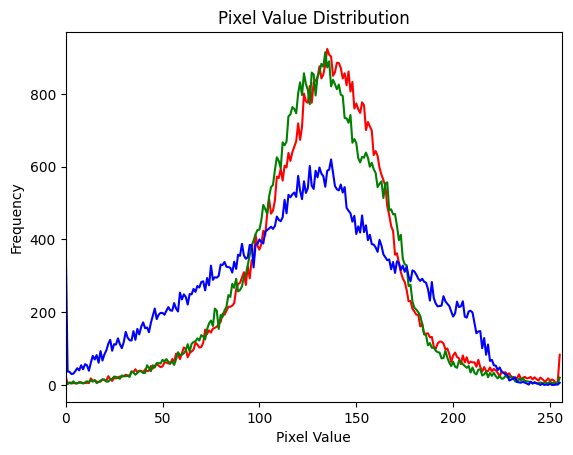

In [23]:
import matplotlib.pyplot as plt
import cv2
import numpy as np

def plot_pixel_histogram(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Plot histograms for each color channel
    color = ('r', 'g', 'b')
    for i, col in enumerate(color):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=col)
        plt.xlim([0, 256])
    
    plt.title('Pixel Value Distribution')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()

# Well lets see what the colors are for the pixels, to understand how the pictures are made
plot_pixel_histogram(os.path.join(monet_jpg_dir, os.listdir(monet_jpg_dir)[0]))


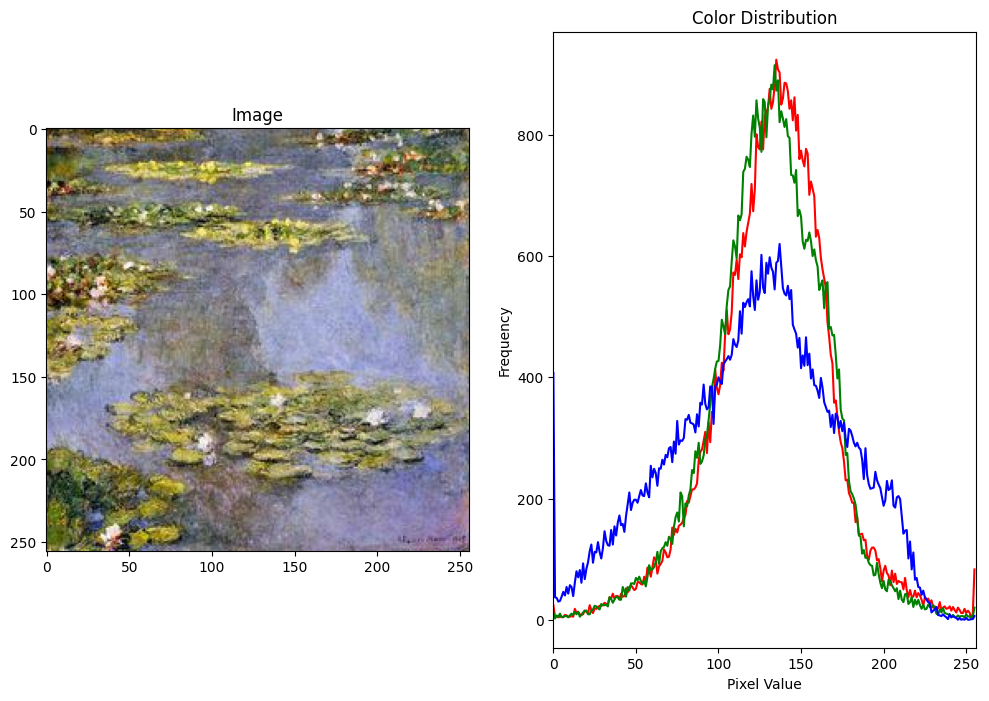

In [24]:
def plot_color_distribution(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(12, 8))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title('Image')
    
    plt.subplot(1, 2, 2)
    for i, color in enumerate(['r', 'g', 'b']):
        hist = cv2.calcHist([image], [i], None, [256], [0, 256])
        plt.plot(hist, color=color)
        plt.xlim([0, 256])
    plt.title('Color Distribution')
    plt.xlabel('Pixel Value')
    plt.ylabel('Frequency')
    plt.show()


plot_color_distribution(os.path.join(monet_jpg_dir, os.listdir(monet_jpg_dir)[0]))


### Honestly from the above, it looks really just blue-ish and green-ish to me. But there are complexities in paintings that I do not understand. 

### Ok, this one was fun for me. The last time I used Fourrier analysis on images was during my final year engineering degree, never thought I would use it again!!! Yay . 

### Frequency analysis, is quite popular in a variety of places though. It just allows us a different angle to look at images. 

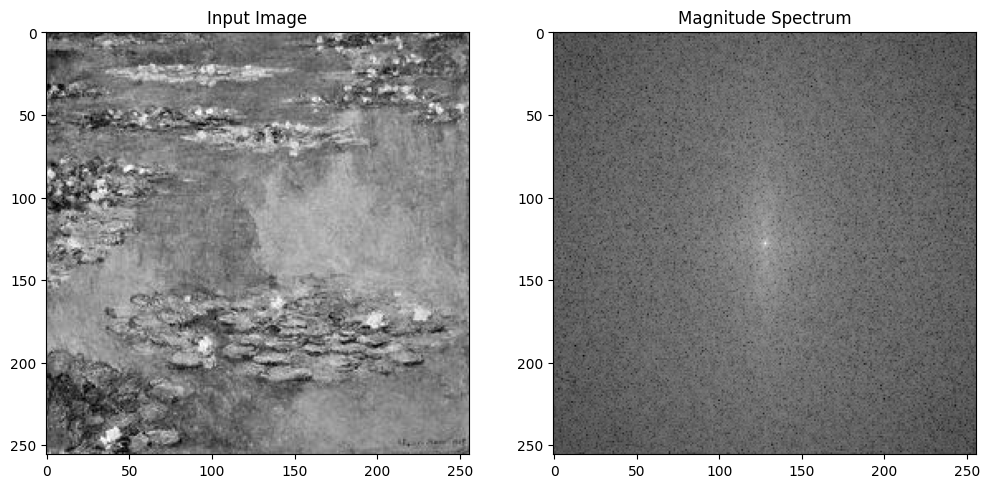

In [25]:
def plot_fourier_transform(image_path):
    image = cv2.imread(image_path, 0)  # Read in grayscale
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    magnitude_spectrum = 20 * np.log(np.abs(fshift))
    
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Input Image')
    
    plt.subplot(1, 2, 2)
    plt.imshow(magnitude_spectrum, cmap='gray')
    plt.title('Magnitude Spectrum')
    plt.show()

plot_fourier_transform(os.path.join(monet_jpg_dir, os.listdir(monet_jpg_dir)[0]))


## Part 2: Learning

### In the event that the Notebook closes, we can save and resume

In [5]:
checkpoint_dir = '/kaggle/working/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

In [6]:
# Mixed precision setup
# Set the global policy to mixed precision
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [7]:
LAMBDA = 10

### The key components that are included below: 
* Generator - used for making images that are far from ideal or incorrect in a lot of ways
* Discriminator - used to actually distinguish between the fakes and real images - here we are using the industry norm of PatchGAN

#### When trained in a loop, they come together to build a close to good enough generator of images

In [8]:
import tensorflow as tf
from tensorflow.keras import layers

# Generator model (U-Net architecture)
def build_generator():
    def downsample(filters, size, apply_batchnorm=True):
        initializer = tf.random_normal_initializer(0., 0.02)
        result = tf.keras.Sequential()
        result.add(layers.Conv2D(filters, size, strides=2, padding='same',
                                 kernel_initializer=initializer, use_bias=False))
        
        if apply_batchnorm:
            result.add(layers.BatchNormalization())
        
        result.add(layers.LeakyReLU())
        return result

    def upsample(filters, size, apply_dropout=False):
        initializer = tf.random_normal_initializer(0., 0.02)
        result = tf.keras.Sequential()
        result.add(layers.Conv2DTranspose(filters, size, strides=2,
                                          padding='same',
                                          kernel_initializer=initializer,
                                          use_bias=False))
        
        result.add(layers.BatchNormalization())
        
        if apply_dropout:
            result.add(layers.Dropout(0.5))
        
        result.add(layers.ReLU())
        return result

    inputs = layers.Input(shape=[256, 256, 3])

    down_stack = [
        downsample(64, 4, apply_batchnorm=False), # (bs, 128, 128, 64)
        downsample(128, 4), # (bs, 64, 64, 128)
        downsample(256, 4), # (bs, 32, 32, 256)
        downsample(512, 4), # (bs, 16, 16, 512)
        downsample(512, 4), # (bs, 8, 8, 512)
        downsample(512, 4), # (bs, 4, 4, 512)
        downsample(512, 4), # (bs, 2, 2, 512)
        downsample(512, 4), # (bs, 1, 1, 512)
    ]

    up_stack = [
        upsample(512, 4, apply_dropout=True), # (bs, 2, 2, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 4, 4, 1024)
        upsample(512, 4, apply_dropout=True), # (bs, 8, 8, 1024)
        upsample(512, 4), # (bs, 16, 16, 1024)
        upsample(256, 4), # (bs, 32, 32, 512)
        upsample(128, 4), # (bs, 64, 64, 256)
        upsample(64, 4),  # (bs, 128, 128, 128)
    ]

    initializer = tf.random_normal_initializer(0., 0.02)
    last = layers.Conv2DTranspose(3, 4,
                                  strides=2,
                                  padding='same',
                                  kernel_initializer=initializer,
                                  activation='tanh') # (bs, 256, 256, 3)

    x = inputs

    # Downsampling through the model
    skips = []
    for down in down_stack:
        x = down(x)
        skips.append(x)

    skips = reversed(skips[:-1])

    # Upsampling and establishing the skip connections
    for up, skip in zip(up_stack, skips):
        x = up(x)
        x = layers.Concatenate()([x, skip])

    x = last(x)

    return tf.keras.Model(inputs=inputs, outputs=x)

# Discriminator model (PatchGAN)
def build_discriminator():
    initializer = tf.random_normal_initializer(0., 0.02)

    inp = layers.Input(shape=[256, 256, 3], name='input_image')
    tar = layers.Input(shape=[256, 256, 3], name='target_image')

    x = layers.concatenate([inp, tar]) # (bs, 256, 256, channels*2)

    down1 = layers.Conv2D(64, 4, strides=2, padding='same',
                          kernel_initializer=initializer)(x) # (bs, 128, 128, 64)
    down1 = layers.LeakyReLU()(down1)

    down2 = layers.Conv2D(128, 4, strides=2, padding='same',
                          kernel_initializer=initializer)(down1) # (bs, 64, 64, 128)
    down2 = layers.BatchNormalization()(down2)
    down2 = layers.LeakyReLU()(down2)

    down3 = layers.Conv2D(256, 4, strides=2, padding='same',
                          kernel_initializer=initializer)(down2) # (bs, 32, 32, 256)
    down3 = layers.BatchNormalization()(down3)
    down3 = layers.LeakyReLU()(down3)

    down4 = layers.Conv2D(512, 4, strides=1, padding='same',
                          kernel_initializer=initializer)(down3) # (bs, 31, 31, 512)
    down4 = layers.BatchNormalization()(down4)
    down4 = layers.LeakyReLU()(down4)

    last = layers.Conv2D(1, 4, strides=1, padding='same',
                         kernel_initializer=initializer)(down4) # (bs, 30, 30, 1)

    return tf.keras.Model(inputs=[inp, tar], outputs=last)


### Much like other learning algorithms we learnt during this course, we also have Loss functions here to whose purpose is to really help improve both the Generator and Discriminator. 
* generator loss - measures how well the generators bad images confuse the discriminator
* discriminator loss - measures how well we can tell bad from good image
* cycle loss - when we transform to and from different styles, is it close to the original images themselves? 
* identity loss - measures how close the image is generated to the original

In [9]:

# Loss functions

def generator_loss(disc_generated_output, generated_image, target_image):
    # Adversarial loss (mean squared error)
    adv_loss = tf.keras.losses.MeanSquaredError()(tf.ones_like(disc_generated_output), disc_generated_output)

    # Ensure both images are of the same dtype before calculating content loss
    generated_image = tf.cast(generated_image, tf.float32)
    target_image = tf.cast(target_image, tf.float32)

    # Content loss (optional)
    content_loss = tf.reduce_mean(tf.abs(target_image - generated_image))

    # Combine the two losses (You can weigh these losses differently)
    total_loss = adv_loss + content_loss
    return total_loss

def discriminator_loss(disc_real_output, disc_generated_output):
    real_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.ones_like(disc_real_output), disc_real_output)
    generated_loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)(tf.zeros_like(disc_generated_output), disc_generated_output)
    return real_loss + generated_loss

def cycle_loss(real_image, cycled_image, LAMBDA):
    # Ensure both images are of the same dtype before calculating the loss
    real_image = tf.cast(real_image, tf.float32)
    cycled_image = tf.cast(cycled_image, tf.float32)
    
    loss = tf.reduce_mean(tf.abs(real_image - cycled_image))
    return LAMBDA * loss

def identity_loss(real_image, same_image, LAMBDA):
    # Ensure both images are of the same dtype before calculating the loss
    real_image = tf.cast(real_image, tf.float32)
    same_image = tf.cast(same_image, tf.float32)
    
    return LAMBDA * 0.5 * tf.reduce_mean(tf.abs(real_image - same_image))

# Build models
generator_g = build_generator()
generator_f = build_generator()
discriminator_x = build_discriminator()
discriminator_y = build_discriminator()

# Optimizers with weight decay (AdamW)
generator_g_optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)
generator_f_optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)
discriminator_x_optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)
discriminator_y_optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4)

# Checkpoint setup
checkpoint = tf.train.Checkpoint(generator_g_optimizer=generator_g_optimizer,
                                 generator_f_optimizer=generator_f_optimizer,
                                 discriminator_x_optimizer=discriminator_x_optimizer,
                                 discriminator_y_optimizer=discriminator_y_optimizer,
                                 generator_g=generator_g,
                                 generator_f=generator_f,
                                 discriminator_x=discriminator_x,
                                 discriminator_y=discriminator_y)
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
latest_checkpoint = tf.train.latest_checkpoint(checkpoint_dir)
if latest_checkpoint:
    checkpoint.restore(latest_checkpoint)
    print(f"Restored from {latest_checkpoint}")
else:
    print("Starting training from scratch.")

# Data loading and preprocessing
def load_image(image_file):
    image = tf.io.read_file(image_file)
    image = tf.image.decode_jpeg(image)
    image = tf.image.resize(image, [256, 256])
    image = (image / 127.5) - 1
    return image

def preprocess_dataset(image_files):
    dataset = tf.data.Dataset.from_tensor_slices(image_files)
    dataset = dataset.map(load_image, num_parallel_calls=tf.data.experimental.AUTOTUNE)
    dataset = dataset.batch(1)
    dataset = dataset.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return dataset

# Prepare datasets
monet_files = [os.path.join(monet_jpg_dir, f) for f in os.listdir(monet_jpg_dir) if f.endswith('.jpg')]
photo_files = [os.path.join(photo_jpg_dir, f) for f in os.listdir(photo_jpg_dir) if f.endswith('.jpg')]

monet_ds = preprocess_dataset(monet_files)
photo_ds = preprocess_dataset(photo_files)

@tf.function
def train_step(real_x, real_y):
    with tf.GradientTape(persistent=True) as tape:
        # Generator forward pass
        fake_y = generator_g(real_x, training=True)
        cycled_x = generator_f(fake_y, training=True)

        fake_x = generator_f(real_y, training=True)
        cycled_y = generator_g(fake_x, training=True)
        
        same_x = generator_f(real_x, training=True)
        same_y = generator_g(real_y, training=True)

        # Discriminator forward pass
        disc_real_y = discriminator_y([real_x, real_y], training=True)
        disc_fake_y = discriminator_y([real_x, fake_y], training=True)

        disc_real_x = discriminator_x([real_y, real_x], training=True)
        disc_fake_x = discriminator_x([real_y, fake_x], training=True)

        # Calculate generator losses
        gen_g_loss = generator_loss(disc_fake_y, fake_y, real_y)
        gen_f_loss = generator_loss(disc_fake_x, fake_x, real_x)

        # Calculate cycle consistency loss with LAMBDA
        total_cycle_loss = cycle_loss(real_x, cycled_x, LAMBDA) + cycle_loss(real_y, cycled_y, LAMBDA)

        # Total generator losses
        total_gen_g_loss = gen_g_loss + total_cycle_loss + identity_loss(real_y, same_y, LAMBDA)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identity_loss(real_x, same_x, LAMBDA)

        # Calculate discriminator losses
        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)

    # Apply gradients
    generator_g_gradients = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    generator_f_gradients = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    discriminator_x_gradients = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    discriminator_y_gradients = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    generator_g_optimizer.apply_gradients(zip(generator_g_gradients, generator_g.trainable_variables))
    generator_f_optimizer.apply_gradients(zip(generator_f_gradients, generator_f.trainable_variables))

    discriminator_x_optimizer.apply_gradients(zip(discriminator_x_gradients, discriminator_x.trainable_variables))
    discriminator_y_optimizer.apply_gradients(zip(discriminator_y_gradients, discriminator_y.trainable_variables))

    del tape  # Free up the tape to save memory

Starting training from scratch.


### In the above train steps and below as well we run a loop (I reduced the epochs to run within the hour), it follows a simple procedure which we have seen before: 

* Generate a bad image
* check whether the discriminator can tell good image from bad? 
* calculate all the losses
* Update weights

### The above then ensures a simple but effective train procedure

In [10]:
# Training loop with checkpointing and limited epochs
EPOCHS = 10  # Start with fewer epochs for quick feedback
initial_epoch = int(latest_checkpoint.split('-')[-1]) if latest_checkpoint else 0

for epoch in range(initial_epoch, EPOCHS):
    n = 0
    for image_x, image_y in tf.data.Dataset.zip((photo_ds, monet_ds)):
        train_step(image_x, image_y)
        if n % 10 == 0:
            print('.', end='', flush=True)
        n += 1
    print(f' Epoch {epoch+1}/{EPOCHS}')
    checkpoint.save(file_prefix=checkpoint_prefix)



2024-08-12 17:07:17.610908: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape infunctional_31_5/sequential_23_1/dropout_3_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


.............................. Epoch 1/10
.............................. Epoch 2/10
.............................. Epoch 3/10
.............................. Epoch 4/10
.............................. Epoch 5/10
.............................. Epoch 6/10
.............................. Epoch 7/10
.............................. Epoch 8/10
.............................. Epoch 9/10
.............................. Epoch 10/10


## Part 3: Generate outputs

In [11]:
# Transform the photos and save the results
output_dir = '/kaggle/output/'
#/kaggle/input/
os.makedirs(output_dir, exist_ok=True)

photo_files = [os.path.join(photo_jpg_dir, f) for f in os.listdir(photo_jpg_dir) if f.endswith('.jpg')]

for i, image_file in enumerate(photo_files[:10000]):
    image = load_image(image_file)
    image = tf.expand_dims(image, axis=0)
    transformed_image = generator_g(image, training=False)
    transformed_image = tf.squeeze(transformed_image, axis=0)
    transformed_image = ((transformed_image + 1) * 127.5).numpy().astype(np.uint8)
    img = Image.fromarray(transformed_image)
    img.save(os.path.join(output_dir, f'image_{i+1}.jpg'))

# Save the images in a zip file
output_zip = 'images.zip'
with zipfile.ZipFile(output_zip, 'w') as zf:
    for root, _, files in os.walk(output_dir):
        for file in files:
            zf.write(os.path.join(root, file), file)

print(f"Generated images saved in {output_zip}")

Generated images saved in images.zip


In [13]:
#!kaggle competitions submit -c gan-getting-started -f images.zip -m "first"

## Conclusions: 

### This is the project that I think I spent the most time on, and learnt the most from. There were a fair amount of complexities which I had to learn and experiment with first to even understand and get a grasp off. 

### The output of 321 in the competition places me in 95th place, not bad for a single submission. But what can be done to improve? 

* The first thing I would do is extend the learning Epochs, at this point I limited it to 10 to save time
* I would also adjust the lambda values to find a better contant to use
* One could also adjust learning rates and the optimizer itself
* Lastly I would look at what could be done to the images, to see if they can be optimized. 